Ensemble de ville avec distances

trouver le plus petit chemin qui relie toutes les villes sans passer par une ville plus d'une fois.



3 heuristique 

plus proche voisin

k-opt 

algorithme génétique

1 individu = une solution possible (une parcours de villes) , genere 100 parcours differents , une fonction d'evaluation (le cout du parcours) , selectionne les meilleurs parcours , croisement (melange de 2 parcours pour en faire un nouveau) , mutation (changer l'ordre de 2 villes dans le parcours)

à la fin afficher le parcours le plus court trouvé et sa distance totale.

# TSP (Travelling Salesman Problem)

In [15]:
import pandas as pd
import numpy as np

from pprint import pprint
import matplotlib.pyplot as plt

from tsp.structure import Ville, DistanceGraph
from tsp.io import load_cities
from tsp.solvers import KNN
from tsp.visualizer import TSPVisualizer



In [16]:
class France:
    """Orchestre l'analyse complète du problème TSP"""

    def __init__(self, villes: list[Ville] = None):  
        self.villes = villes if villes is not None else []
        self.graph = DistanceGraph(self.villes)
        
        # Calculer les distances dans chaque ville
        self.calculer_distances()
        
        # Créer le solveur KNN
        self.knn = KNN(self.graph)
        
        # Créer le visualizer
        self.visualizer = TSPVisualizer(self.graph, self.knn)
        
        self.best_path = None

    def __str__(self):
        return f'France: {", ".join([v.nom for v in self.villes])}'

    def calculer_distances(self):
        """Calcule les distances entre toutes les villes"""
        for v in self.villes:
            for ville in self.villes:
                if v.nom != ville.nom:
                    v.distance[f'{ville.nom}'] = v.eucledian_distance(ville)
                else:
                    v.distance[f'{ville.nom}'] = 0

    def get_matrix_with_labels(self):
        """Retourne la matrice de distances avec labels"""
        return self.graph.get_dataframe()
    
    def compute_all_paths(self):
        """Résout depuis tous les points de départ"""
        self.knn.compute_all_paths()
            
    def compute_path_distance(self, path):
        """Calcule la distance totale d'un chemin"""
        indices = [self.graph.index[nom] for nom in path]
        rows = indices[:-1]
        cols = indices[1:]
        return np.sum(self.graph.matrix[rows, cols])
    
    def print_distance_from_each_city(self):
        """Affiche les distances pour chaque point de départ"""
        self.knn.print_distance_from_each_city()

    def print_from_a_city(self, nom_ville):
        """Affiche le chemin partant d'une ville"""
        return self.knn.print_from_a_city(nom_ville)
    
    def get_optimal_path(self):
        """Retourne le meilleur chemin"""
        start_point, path, distance = self.knn.get_optimal_path()
        self.best_path = path
        return start_point, path, distance
    
    def plot_path(self):
        """Affiche le meilleur chemin trouvé"""
        if self.best_path is None:
            print("Veuillez d'abord appeler get_optimal_path()")
            return
        
        self.visualizer.plot_path(self.best_path, "Chemin optimal à travers les villes")


In [17]:
def process_france_travel(file_path: str, separator: str = ";"):
    try:
        # Charger les villes
        villes = load_cities(file_path, separator)
        
        # Créer l'objet France
        france = France(villes)

        print(f"--- Analyse terminée pour : {file_path} ---")
        
        print("\nMatrice de distances :")
        print(france.get_matrix_with_labels())
        
        print("\nChemin trouvés :")
        france.compute_all_paths()
        
        print("\nDistance totale par point de départ :")
        france.print_distance_from_each_city()
        
        print("\nMeilleur chemin trouvé :")
        start_point, path, distance = france.get_optimal_path()
        print(f"Point de départ {start_point}")
        print(f"Chemin {path}")
        print(f"Distance : {distance}")
        
        return france

    except FileNotFoundError:
        print(f"Erreur : Le fichier {file_path} est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")

--- Analyse terminée pour : ../data/fr-10.csv ---

Matrice de distances :
                Paris  Bordeaux  Marseille      Lyon  Toulouse      Nice  \
Paris        0.000000  4.973095   6.326457  3.972241  5.330144  7.120736   
Bordeaux     4.973095  0.000000   6.146967  5.497527  2.371294  7.928195   
Marseille    6.326457  6.146967   0.000000  2.519965  3.938071  1.939485   
Lyon         3.972241  5.497527   2.519965  0.000000  4.022312  3.180650   
Toulouse     5.330144  2.371294   3.938071  4.022312  0.000000  5.823140   
Nice         7.120736  7.928195   1.939485  3.180650  5.823140  0.000000   
Nantes       4.234859  2.569377   7.956437  6.556977  4.694562  9.493663   
Montpellier  5.462010  4.623296   1.525776  2.354000  2.433211  3.390335   
Strasbourg   5.400525  9.128595   5.796183  4.051505  8.031260  4.903401   
Lille        1.906665  6.836363   7.687222  5.183621  7.206435  8.102751   

               Nantes  Montpellier  Strasbourg     Lille  
Paris        4.234859     5.46

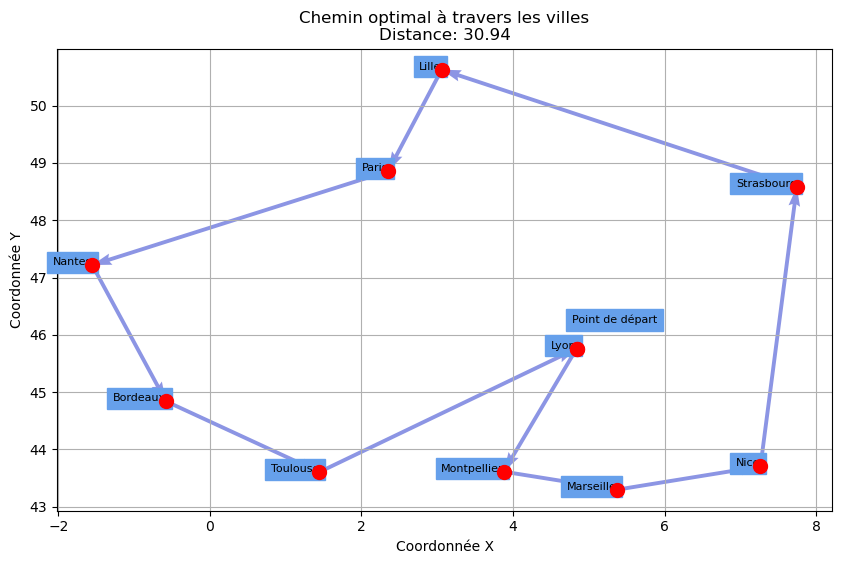

In [18]:
france10 = process_france_travel("../data/fr-10.csv")

france10.plot_path()

--- Analyse terminée pour : ../data/fr-100.csv ---

Matrice de distances :
                     Paris  Bordeaux  Marseille      Lyon  Toulouse      Nice  \
Paris             0.000000  4.973095   6.326457  3.972241  5.330144  7.120736   
Bordeaux          4.973095  0.000000   6.146967  5.497527  2.371294  7.928195   
Marseille         6.326457  6.146967   0.000000  2.519965  3.938071  1.939485   
Lyon              3.972241  5.497527   2.519965  0.000000  4.022312  3.180650   
Toulouse          5.330144  2.371294   3.938071  4.022312  0.000000  5.823140   
...                    ...       ...        ...       ...       ...       ...   
Bayonne           6.594484  1.622498   6.852735  6.715303  2.926241  8.748903   
Corbeil-Essonnes  0.275318  4.859852   6.051145  3.702014  5.115812  6.855840   
Cagnes-sur-Mer    7.068827  7.817796   1.816565  3.118102  5.705214  0.123708   
Vaulx-en-Velin    4.009014  5.577831   2.521140  0.080375  4.097772  3.132201   
Sevran            0.196634  5.1427

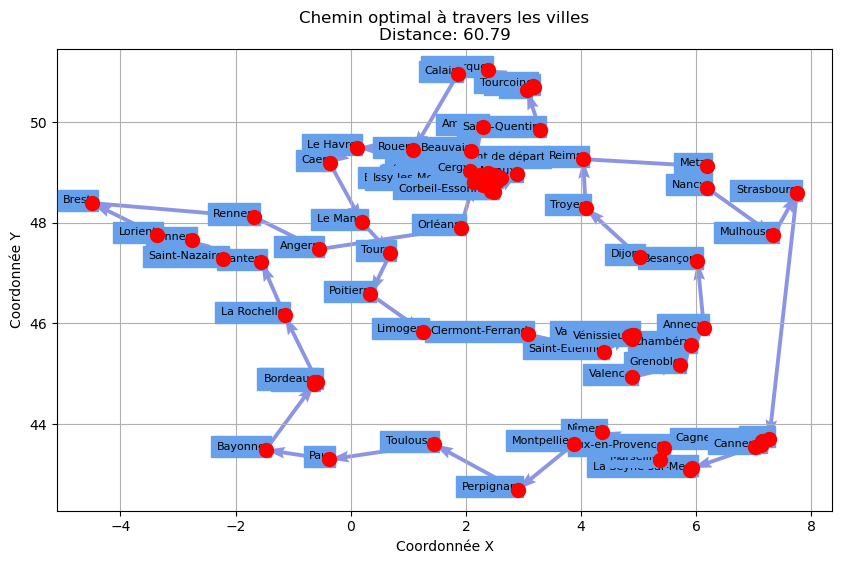

In [19]:
france100 = process_france_travel("../data/fr-100.csv")
france100.plot_path()

Approche k-opt

In [20]:
# france = process_france_travel("../data/fr.csv")

